# Figure 1 — Per-chromosome coverage and sex inference

Revised for Reviewer #2. Coverage from the mapped, deduplicated BAM, keeping reads with
**MAPQ ≥ 10** (uniquely-mapping). The strongest multi-mapping pileups (e.g. the Yq12/DYZ1
satellite, which sit at MAPQ 0) are thereby removed. (Genotyping itself uses the stricter
`mpileup -q30`; the coverage here is intentionally more permissive.)

Both panels use **mappable sequence only**: the reference assembly gaps / heterochromatin
(centromeres, 1q/9q/16q blocks, acrocentric p-arms, Yq12) and the pseudoautosomal regions
(PAR1/PAR2 on X & Y) are excluded. Gaps are detected as depth-0 runs ≥ 0.5 Mb in the
all-reads coverage (they reproduce the GRCh37 assembly gaps; UCSC hg19 gap track). chrY is
restricted to its assembled male-specific euchromatin (0–28.82 Mb; the 28.82–58.82 Mb Yq12
heterochromatin is a 30 Mb N-gap — Skaletsky et al. 2003, Nature 423:825).

- **Panel A** — mean depth ± SD (1 Mb windows) per chromosome, over mappable sequence.
  Autosomes uniform; chrX ≈ ½ the autosomal mean; chrY low → male.
- **Panel B** — coverage profile, X axis = % of each chromosome's mappable length (5 Mb windows).

In [13]:
import os, subprocess
import numpy as np
import pandas as pd

# ---- Config ----
DATA    = "/Users/ethelvol/research/sample_1948"
BAM     = f"{DATA}/JD206_libmerged_rg_rmdup.mapped.bam"   # mapped, deduplicated reads
MAPQ    = 10                                              # mapping-quality filter (>=10); keeps more of the repetitive Y than the stricter q30 genotyping filter
MQBAM   = f"{DATA}/JD206_mapq{MAPQ}.bam"
BED     = f"{DATA}/coverage_mapq{MAPQ}.bed"               # per-interval depth at MAPQ>={MAPQ} (BEDGRAPH)
BED_ALL = f"{DATA}/coverage.bed"                          # all reads -> detect assembly gaps
CHROMS  = [str(i) for i in range(1, 23)] + ["X", "Y"]

WIN_A, WIN_B = 1_000_000, 5_000_000     # Panel A SD window; Panel B profile window

# PARs (excluded on X & Y); chrY mappable-euchromatin end for the Panel B % axis.
PAR = {"X": [(60001, 2699520), (154931044, 155260560)],
       "Y": [(10001, 2649520), (59034050, 59373566)], "1": []}
Y_EUCHR_END = 28_819_151          # GRCh37 Yq12 N-gap start (28.82-58.82 Mb, 30 Mb; Skaletsky 2003)
EFF = {"Y": Y_EUCHR_END}
GAP_MIN      = 500_000            # depth-0 run (all reads) >= this = assembly gap / heterochromatin
MIN_MAPPABLE = 200_000           # a window needs this much mappable (non-excluded) sequence to count
MIN_NONPAR   = WIN_B // 10

# ---- MAPQ-filtered per-interval coverage (expensive; generated once) ----
if not os.path.exists(BED):
    print(f"Generating MAPQ>={MAPQ} coverage (one-time)...")
    subprocess.run(f"samtools view -b -q {MAPQ} {BAM} > {MQBAM} && samtools index {MQBAM} "
                   f"&& bedtools genomecov -ibam {MQBAM} -bga > {BED}", shell=True, check=True)
else:
    print("Using existing", BED)

cov = pd.read_csv(BED, sep="\t", header=None, names=["chrom","start","end","depth"],
                  dtype={"chrom":str,"start":np.int64,"end":np.int64,"depth":np.float64})
cov = cov[cov.chrom.isin(CHROMS)]

# ---- Assembly gaps / heterochromatin = long depth-0 runs in the all-reads coverage ----
# At ~0.066x a mappable >=0.5 Mb stretch never has zero reads, so these are the reference
# N-gaps (centromeres, 1q/9q/16q heterochromatin, acrocentric p-arms, Yq12).
_allc = pd.read_csv(BED_ALL, sep="\t", header=None, names=["chrom","start","end","depth"],
                    dtype={"chrom":str,"start":np.int64,"end":np.int64,"depth":np.float64})
_allc = _allc[_allc.chrom.isin(CHROMS)]
GAPS = {c: [(int(r.start), int(r.end)) for r in
            _allc[(_allc.chrom==c)&(_allc.depth==0)&(_allc.end-_allc.start>=GAP_MIN)].itertuples()]
        for c in CHROMS}

def _cum(chrom):
    """C(x) = integral of depth over [0, x] (vectorized), and chromosome length L."""
    sub = cov[cov.chrom==chrom]
    s,e,d = sub.start.to_numpy(), sub.end.to_numpy(), sub.depth.to_numpy()
    ce = np.cumsum(d*(e-s)); cs = ce - d*(e-s)
    def C(x):
        x=np.asarray(x,float); i=np.clip(np.searchsorted(e,x,side="right"),0,len(e)-1)
        return cs[i]+d[i]*(x-s[i])
    return C, e[-1]

def _excl(C, intervals, a, b):
    """Depth-integral and length of `intervals` overlapping each window [a,b)."""
    ii = np.zeros_like(a, float); ll = np.zeros_like(a, float)
    for p0, p1 in intervals:
        o0, o1 = np.clip(a, p0, p1), np.clip(b, p0, p1)
        ii += C(o1) - C(o0); ll += (o1 - o0)
    return ii, ll

# ---- Panel A: mean depth + SD over MAPPABLE sequence (gaps + PAR excluded) ----
# Same masking as Panel B so the two panels are consistent: N-gaps/heterochromatin AND the
# pseudoautosomal regions are removed, and chrY is restricted to its MSY euchromatin (0-28.82 Mb).
# (PAR reads on Y are near-empty because their homologue maps to X, so keeping PAR would
#  artificially deflate the Y bar and make it disagree with Panel B.)
rows = []
for chrom in CHROMS:
    C, L = _cum(chrom)
    eff = EFF.get(chrom, L)                        # Y -> MSY euchromatin end; others -> full length
    exclude = GAPS[chrom] + PAR.get(chrom, [])     # N-gaps/heterochromatin AND PAR1/PAR2 (X & Y)
    ex_i, ex_l = _excl(C, exclude, np.array([0.0]), np.array([float(eff)]))
    mean_depth = (C(np.array([float(eff)]))[0] - ex_i[0]) / (eff - ex_l[0])
    edges = np.append(np.arange(0, eff, WIN_A, dtype=np.int64), eff)
    a, b = edges[:-1].astype(float), edges[1:].astype(float)
    ei, el = _excl(C, exclude, a, b)
    mi, ml = (C(b)-C(a)) - ei, (b-a) - el
    with np.errstate(invalid="ignore", divide="ignore"):
        wm = np.where(ml >= MIN_MAPPABLE, mi/ml, np.nan)
    rows.append((chrom, mean_depth, float(np.nanstd(wm))))
stats = pd.DataFrame(rows, columns=["chrom","mean_depth","sd_windows"])
auto_mean = stats.loc[~stats.chrom.isin(["X","Y"]), "mean_depth"].mean()

# ---- Panel B: PAR-masked profile; X axis = % of mappable length (Y -> MSY euchromatin) ----
def profile_pct(chrom):
    C, L_full = _cum(chrom)
    eff = EFF.get(chrom, L_full)
    edges = np.append(np.arange(0, eff, WIN_B, dtype=np.int64), eff)
    a, b = edges[:-1].astype(float), edges[1:].astype(float)
    ei, el = _excl(C, PAR.get(chrom, []), a, b)
    mi, ml = (C(b)-C(a)) - ei, (b-a) - el
    with np.errstate(invalid="ignore", divide="ignore"):
        m = np.where(ml >= MIN_NONPAR, mi/ml, np.nan)
    return (a+b)/2/eff*100.0, m
pct_profiles = {c: profile_pct(c) for c in ["1","X","Y"]}

si = stats.set_index("chrom")
print(stats.to_string(index=False))
print(f"\nMappable autosomal {auto_mean:.4f}; X {si.loc['X','mean_depth']:.4f} "
      f"(X/auto={si.loc['X','mean_depth']/auto_mean:.2f}); Y {si.loc['Y','mean_depth']:.4f} "
      f"(Y/auto={si.loc['Y','mean_depth']/auto_mean:.2f})")

Using existing /Users/ethelvol/research/sample_1948/coverage_mapq10.bed
chrom  mean_depth  sd_windows
    1    0.059094    0.012811
    2    0.057148    0.010412
    3    0.056956    0.008532
    4    0.053980    0.008105
    5    0.055090    0.009465
    6    0.057021    0.008369
    7    0.057235    0.010930
    8    0.057195    0.009440
    9    0.054875    0.020758
   10    0.059558    0.010407
   11    0.060103    0.011598
   12    0.060512    0.009684
   13    0.053745    0.007244
   14    0.059309    0.011518
   15    0.058635    0.011042
   16    0.065796    0.013501
   17    0.067439    0.010685
   18    0.057269    0.008129
   19    0.074758    0.011875
   20    0.066083    0.010335
   21    0.059347    0.013577
   22    0.070634    0.015684
    X    0.026996    0.004193
    Y    0.019348    0.010124

Mappable autosomal 0.0601; X 0.0270 (X/auto=0.45); Y 0.0193 (Y/auto=0.32)


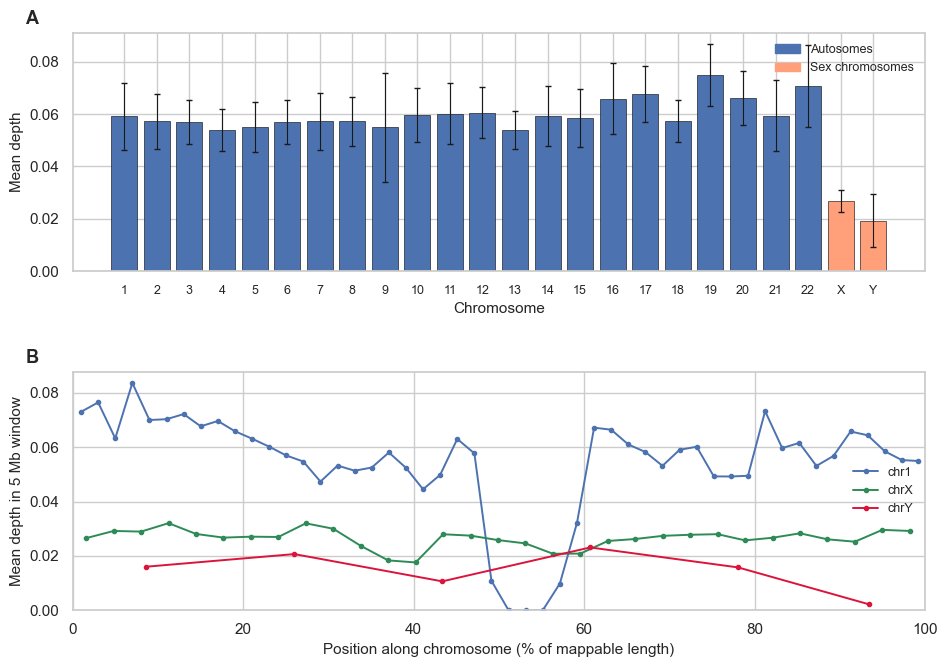

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

order = [str(i) for i in range(1, 23)] + ["X", "Y"]
s = stats.set_index("chrom").loc[order].reset_index()
is_sex = s["chrom"].isin(["X", "Y"]).to_numpy()
colors = np.where(is_sex, "lightsalmon", "#4C72B0")
mean, sd = s["mean_depth"].to_numpy(), s["sd_windows"].to_numpy()

fig = plt.figure(figsize=(11, 7.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.42)

# ---- Panel A: mean +/- SD per chromosome, over mappable sequence ----
axA = fig.add_subplot(gs[0]); x = np.arange(len(s))
axA.bar(x, mean, yerr=[np.minimum(sd, mean), sd], color=colors, edgecolor="black",
        linewidth=0.4, capsize=2.5, error_kw=dict(lw=0.8))
axA.set_xticks(x); axA.set_xticklabels(s["chrom"], fontsize=9)
axA.set_xlabel("Chromosome", fontsize=11)
axA.set_ylabel("Mean depth", fontsize=11)
# axA.axhline(auto_mean, color="gray", ls="--", lw=0.8, zorder=0)
# axA.axhline(auto_mean / 2, color="darkorange", ls=":", lw=0.9, zorder=0)
# axA.text(0.5, auto_mean + 0.001, "autosomal mean", fontsize=7.5, color="gray")
# axA.text(0.5, auto_mean / 2 + 0.001, "half of autosomal mean", fontsize=7.5, color="darkorange")
axA.text(-0.055, 1.02, "A", transform=axA.transAxes, fontsize=13, fontweight="bold", va="bottom")
axA.legend(handles=[Patch(color="#4C72B0", label="Autosomes"),
                    Patch(color="lightsalmon", label="Sex chromosomes")],
           fontsize=9, frameon=False, loc="upper right")

# ---- Panel B: coverage profile, X axis = % of mappable length (Y normalized to MSY) ----
axB = fig.add_subplot(gs[1])
for chrom, col in [("1", "#4C72B0"), ("X", "seagreen"), ("Y", "crimson")]:
    pct, m = pct_profiles[chrom]
    axB.plot(pct, m, color=col, lw=1.4, marker="o", ms=3, label="chr" + chrom)
axB.set_xlim(0, 100)
axB.set_xlabel("Position along chromosome (% of mappable length)", fontsize=11)
axB.set_ylabel(f"Mean depth in {WIN_B//10**6} Mb window", fontsize=11)
axB.text(-0.055, 1.02, "B", transform=axB.transAxes, fontsize=13, fontweight="bold", va="bottom")
axB.set_ylim(bottom=0); axB.legend(fontsize=9, frameon=False)

for ext in ("png", "pdf"):
    fig.savefig(f"/Users/ethelvol/research/paper_1948_code/Figure1_coverage.{ext}",
                dpi=300, bbox_inches="tight")
plt.show()

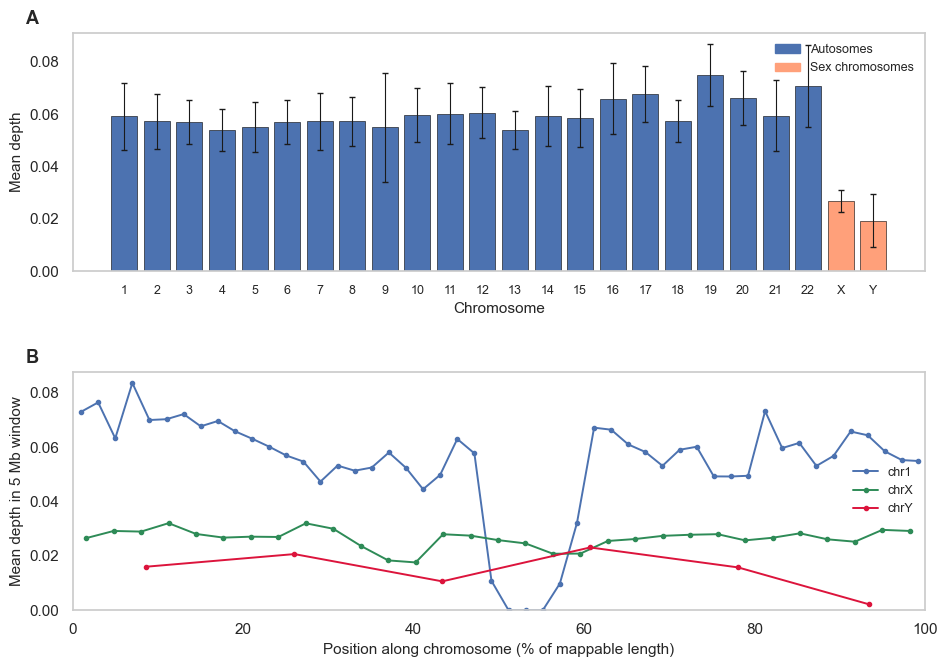

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import numpy as np

order = [str(i) for i in range(1, 23)] + ["X", "Y"]
s = stats.set_index("chrom").loc[order].reset_index()
is_sex = s["chrom"].isin(["X", "Y"]).to_numpy()
colors = np.where(is_sex, "lightsalmon", "#4C72B0")
mean, sd = s["mean_depth"].to_numpy(), s["sd_windows"].to_numpy()

fig = plt.figure(figsize=(11, 7.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.42)

# ---- Panel A: mean +/- SD per chromosome, over mappable sequence ----
axA = fig.add_subplot(gs[0]); x = np.arange(len(s))
axA.bar(x, mean, yerr=[np.minimum(sd, mean), sd], color=colors, edgecolor="black",
        linewidth=0.4, capsize=2.5, error_kw=dict(lw=0.8))
axA.set_xticks(x); axA.set_xticklabels(s["chrom"], fontsize=9)
axA.set_xlabel("Chromosome", fontsize=11)
axA.set_ylabel("Mean depth", fontsize=11)

# Remove top and right spines (borders) and disable grid lines
#axA.spines['top'].set_visible(False)
#axA.spines['right'].set_visible(False)
axA.grid(False) # Ensures no background grid lines are drawn

axA.text(-0.055, 1.02, "A", transform=axA.transAxes, fontsize=13, fontweight="bold", va="bottom")
axA.legend(handles=[Patch(color="#4C72B0", label="Autosomes"),
                    Patch(color="lightsalmon", label="Sex chromosomes")],
           fontsize=9, frameon=False, loc="upper right")

# ---- Panel B: coverage profile, X axis = % of mappable length (Y normalized to MSY) ----
axB = fig.add_subplot(gs[1])
for chrom, col in [("1", "#4C72B0"), ("X", "seagreen"), ("Y", "crimson")]:
    pct, m = pct_profiles[chrom]
    axB.plot(pct, m, color=col, lw=1.4, marker="o", ms=3, label="chr" + chrom)
axB.set_xlim(0, 100)
axB.set_xlabel("Position along chromosome (% of mappable length)", fontsize=11)
axB.set_ylabel(f"Mean depth in {WIN_B//10**6} Mb window", fontsize=11)

# Remove top and right spines (borders) and disable grid lines
# axB.spines['top'].set_visible(False)
# axB.spines['right'].set_visible(False)
axB.grid(False)

axB.text(-0.055, 1.02, "B", transform=axB.transAxes, fontsize=13, fontweight="bold", va="bottom")
axB.set_ylim(bottom=0); axB.legend(fontsize=9, frameon=False)

for ext in ("png", "pdf"):
    fig.savefig(f"/Users/ethelvol/research/paper_1948_code/Figure1_coverage.{ext}",
                dpi=300, bbox_inches="tight")
plt.show()

In [15]:
import multiprocessing as mp
import concurrent.futures
import pandas as pd
import subprocess
import re

BAM_FILE = f"{DATA}/JD206_libmerged_rg_rmdup.mapped.bam" 
CORES = 6
def get_chrom_coverage(chrom):
    """
    Executes samtools coverage for a specific chromosome and parses the output.
    """
    cmd = ["samtools", "coverage", "-r", chrom, BAM_FILE]
    try:
        # Run samtools and capture the standard output
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        lines = result.stdout.strip().split('\n')
        
        # Ensure we have data beyond the header line
        if len(lines) < 2:
            return None

        data = lines[1].split('\t')
        
        # Extract relevant metrics based on samtools coverage output columns
        rname = data[0]
        coverage_pct = float(data[5])  # Percentage of bases with depth >= 1
        mean_depth = float(data[6])    # Mean depth of coverage
        
        # Calculate % loci with 0 coverage
        zero_cov_pct = 100.0 - coverage_pct

        return {
            "Chromosome": rname,
            "Mean Coverage": mean_depth,
            "% Loci with 0 Coverage": zero_cov_pct
        }
    except subprocess.CalledProcessError as e:
        print(f"Subprocess error on {chrom}: {e}")
        return None

# 1. Dynamically retrieve chromosome names and lengths using samtools idxstats
idx_cmd = ["samtools", "idxstats", BAM_FILE]
idx_result = subprocess.run(idx_cmd, capture_output=True, text=True, check=True)

chroms = []
for line in idx_result.stdout.strip().split('\n'):
    parts = line.split('\t')
    if len(parts) >= 2:
        chrom = parts[0]
        length = int(parts[1])
        # Filter out unplaced contigs to keep data clean
        if length > 1_000_000 and chrom != '*':
            chroms.append(chrom)

print(f"Calculating coverage for {len(chroms)} chromosomes using {CORES} threads...")

# 2. Distribute calculations across 6 threads (avoids Jupyter multiprocessing pickling errors)
with concurrent.futures.ThreadPoolExecutor(max_workers=CORES) as executor:
    # Map preserves the order of results
    results = list(executor.map(get_chrom_coverage, chroms))

# 3. Compile and sort the results into a Pandas DataFrame
results = [r for r in results if r is not None]
df_coverage = pd.DataFrame(results)

# Natural alphanumeric sorting (ensures chr10 comes after chr9, not chr1)
def natural_sort_key(s, _nsre=re.compile('([0-9]+)')):
    return [int(text) if text.isdigit() else text.lower() for text in _nsre.split(s)]

df_coverage['Chromosome'] = pd.Categorical(
    df_coverage['Chromosome'], 
    categories=sorted(df_coverage['Chromosome'].unique(), key=natural_sort_key), 
    ordered=True
)
df_coverage = df_coverage.sort_values('Chromosome').reset_index(drop=True)

# Display the tabular results
display(df_coverage)

Calculating coverage for 25 chromosomes using 6 threads...


,Chromosome,Mean Coverage,% Loci with 0 Coverage
0,1,0.066346,94.11035
1,2,0.067663,94.07427
2,3,0.062989,94.24047
3,4,0.061911,94.38245
4,5,0.064160,94.18739
5,6,0.063964,94.23979
6,7,0.068873,93.84189
7,8,0.068419,94.07236
8,9,0.064272,94.22135
9,10,0.068085,93.86226


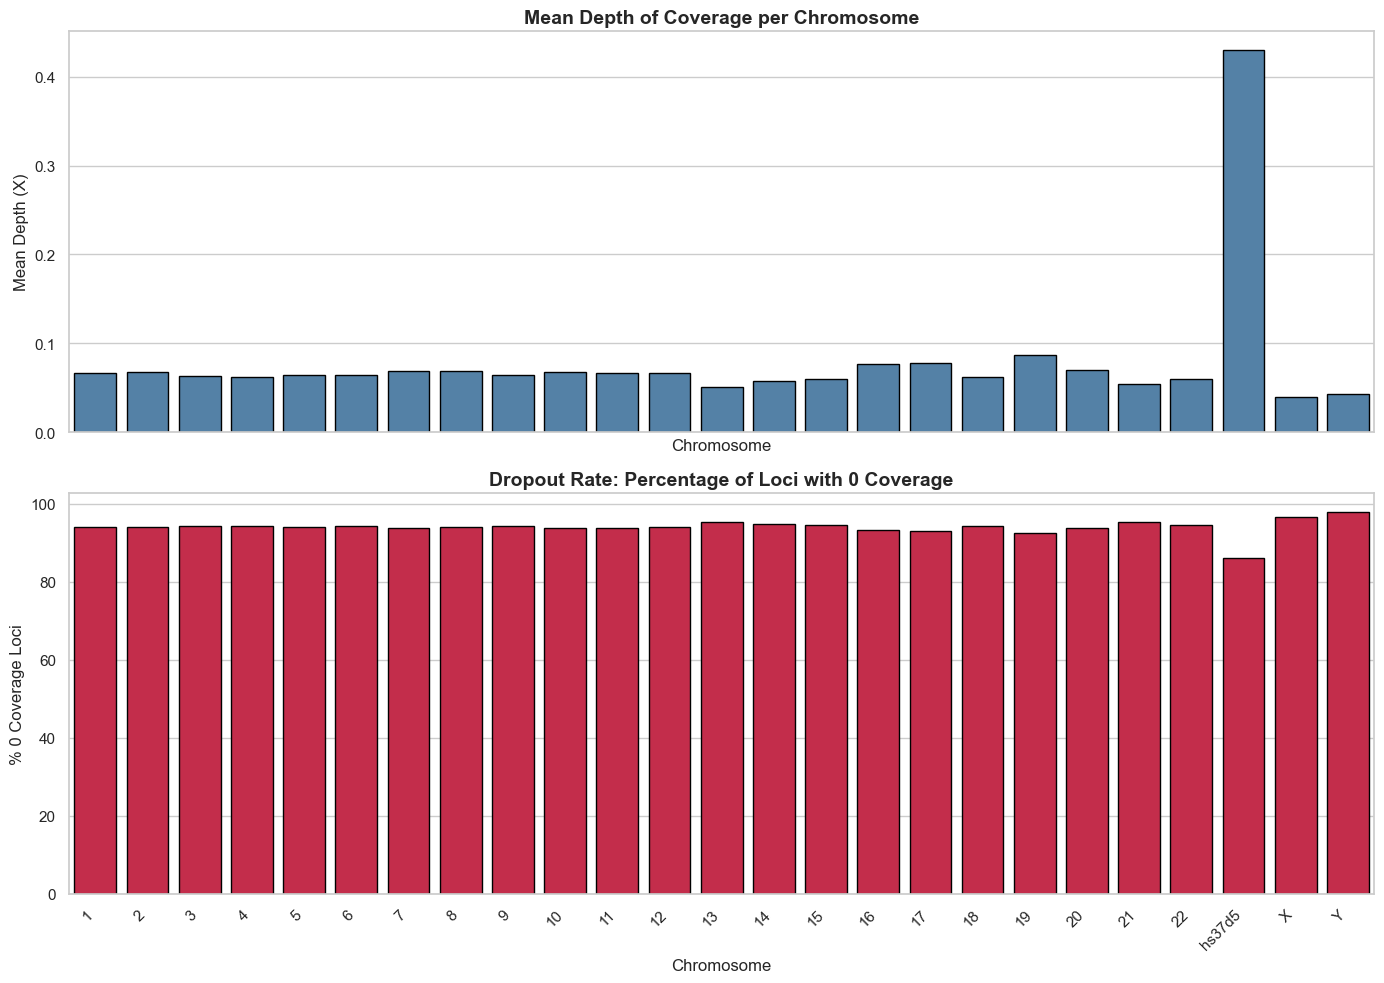

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual aesthetics
#sns.set_theme(style="whitegrid")

# Create a 2-row figure sharing the same X-axis
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top Subplot: Mean Coverage
sns.barplot(
    data=df_coverage, 
    x="Chromosome", 
    y="Mean Coverage", 
    ax=axes[0], 
    color="steelblue",
    edgecolor="black"
)
axes[0].set_title("Mean Depth of Coverage per Chromosome", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Mean Depth (X)", fontsize=12)

# Bottom Subplot: Percentage of Loci with 0 Coverage
sns.barplot(
    data=df_coverage, 
    x="Chromosome", 
    y="% Loci with 0 Coverage", 
    ax=axes[1], 
    color="crimson",
    edgecolor="black"
)
axes[1].set_title("Dropout Rate: Percentage of Loci with 0 Coverage", fontsize=14, fontweight="bold")
axes[1].set_ylabel("% 0 Coverage Loci", fontsize=12)
axes[1].set_xlabel("Chromosome", fontsize=12)

# Format the X-axis to prevent label overlap
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [11]:
import concurrent.futures
import pandas as pd
import subprocess
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration
BAM_FILE = f"{DATA}/JD206_libmerged_rg_rmdup.mapped.bam" 
THREADS = 6
# Window size for the along-chromosome comparison plot (e.g., 100kbp)
WINDOW_SIZE = 100_000 

# Set visual style
sns.set_theme(style="whitegrid")

In [12]:
def get_detailed_chrom_stats(chrom, bam_file):
    """
    Executes samtools depth for a chromosome and calculates Mean, SD, 
    and % 0-coverage streamingly to save memory.
    """
    # -aa forces samtools to output EVERY position, including 0 depth
    cmd = ["samtools", "depth", "-aa", "-r", chrom, bam_file]
    
    n = 0
    sum_depth = 0.0
    sum_sq_depth = 0.0
    zero_cov_bases = 0
    
    try:
        # Start the process
        proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, text=True, bufsize=10**6)
        
        # Read stdout line by line (streaming)
        for line in proc.stdout:
            # Format: chrom \t pos \t depth
            parts = line.strip().split('\t')
            if len(parts) < 3:
                continue
            
            depth = int(parts[2])
            
            n += 1
            sum_depth += depth
            sum_sq_depth += (depth * depth)
            if depth == 0:
                zero_cov_bases += 1
                
        proc.stdout.close()
        proc.wait()
        
        if n == 0:
            return None

        # Calculate statistics
        mean_depth = sum_depth / n
        
        # Sample Standard Deviation formula: sqrt((sum(x^2) - (sum(x)^2 / n)) / (n - 1))
        # Note: If n is very large, sum_sq_depth can overflow float64 precision. 
        # For human chromosomes, it's usually okay.
        numerator = sum_sq_depth - ((sum_depth * sum_depth) / n)
        if numerator < 0: numerator = 0 # Handle tiny precision errors
        
        # Using Sample SD (n-1), change to population SD (n) if preferred.
        if n > 1:
            sd_depth = np.sqrt(numerator / (n - 1))
        else:
            sd_depth = 0.0
            
        pct_zero_cov = (zero_cov_bases / n) * 100.0

        return {
            "Chromosome": chrom,
            "Length": n,
            "Mean Coverage": mean_depth,
            "SD Coverage": sd_depth,
            "% Loci with 0 Coverage": pct_zero_cov
        }

    except Exception as e:
        print(f"Error processing {chrom}: {e}")
        return None

# 1. Dynamically retrieve chromosome names using samtools idxstats
print(f"Retrieving chromosome list...")
idx_cmd = ["samtools", "idxstats", BAM_FILE]
idx_result = subprocess.run(idx_cmd, capture_output=True, text=True, check=True)

chroms_to_process = []
available_chroms = []
for line in idx_result.stdout.strip().split('\n'):
    parts = line.split('\t')
    if len(parts) >= 2:
        chrom = parts[0]
        length = int(parts[1])
        available_chroms.append(chrom)
        # Filter for main chromosomes (>1Mbp) for Figure 1, excluding '*'
        if length > 1_000_000 and chrom != '*':
            chroms_to_process.append(chrom)

print(f"Calculating detailed coverage stats (Mean, SD, % 0-Cov) for "
      f"{len(chroms_to_process)} chromosomes using {THREADS} threads. This may take a few minutes...")

# 2. Parallel execution using ThreadPool
results = []
with concurrent.futures.ThreadPoolExecutor(max_workers=THREADS) as executor:
    # Use dict to map future to chrom name for error tracking
    future_to_chrom = {executor.submit(get_detailed_chrom_stats, chrom, BAM_FILE): chrom for chrom in chroms_to_process}
    
    for future in concurrent.futures.as_completed(future_to_chrom):
        chrom = future_to_chrom[future]
        try:
            data = future.result()
            if data:
                results.append(data)
        except Exception as e:
            print(f"Chromosome {chrom} generated an exception: {e}")

# 3. Create DataFrame and Sort naturally
df_fig1 = pd.DataFrame(results)

def natural_sort_key(s, _nsre=re.compile('([0-9]+)')):
    return [int(text) if text.isdigit() else text.lower() for text in _nsre.split(s)]

sorted_categories = sorted(df_fig1['Chromosome'].unique(), key=natural_sort_key)
df_fig1['Chromosome'] = pd.Categorical(df_fig1['Chromosome'], categories=sorted_categories, ordered=True)
df_fig1 = df_fig1.sort_values('Chromosome').reset_index(drop=True)

print("Processing complete.")
display(df_fig1.head())

Retrieving chromosome list...
Calculating detailed coverage stats (Mean, SD, % 0-Cov) for 25 chromosomes using 6 threads. This may take a few minutes...
Processing complete.


,Chromosome,Length,Mean Coverage,SD Coverage,% Loci with 0 Coverage
0,1,249250621,0.066346,0.595289,94.110346
1,2,243199373,0.067662,2.025897,94.074273
2,3,198022430,0.062989,0.304170,94.240475
3,4,191154276,0.061911,0.307583,94.382451
4,5,180915260,0.064160,0.301835,94.187395


In [23]:
df_fig1 = df_fig1[~(df_fig1.Chromosome == 'hs37d5')]

In [25]:
df_fig1

,Chromosome,Length,Mean Coverage,SD Coverage,% Loci with 0 Coverage
0,1,249250621,0.066346,0.595289,94.110346
1,2,243199373,0.067662,2.025897,94.074273
2,3,198022430,0.062989,0.304170,94.240475
3,4,191154276,0.061911,0.307583,94.382451
4,5,180915260,0.064160,0.301835,94.187395
5,6,171115067,0.063964,0.359833,94.239794
6,7,159138663,0.068873,0.586176,93.841895
7,8,146364022,0.068419,0.556940,94.072357
8,9,141213431,0.064272,0.667969,94.221346
9,10,135534747,0.068085,0.544485,93.862255


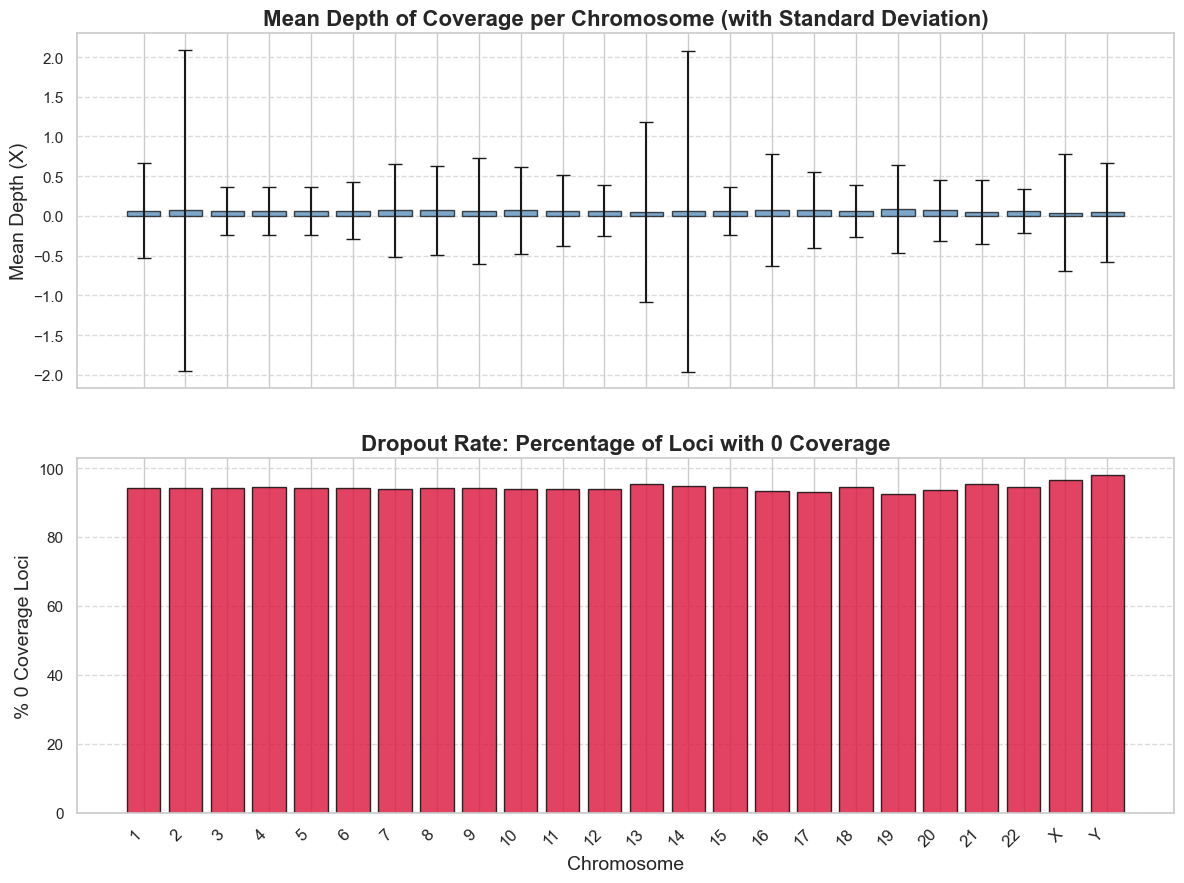

In [27]:
# Create a 2-row figure sharing the same X-axis
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

chrom_labels = df_fig1['Chromosome'].tolist()
x_pos = np.arange(len(chrom_labels))

# --- Top Subplot: Mean Coverage with Standard Deviation Error Bars ---
means = df_fig1['Mean Coverage'].tolist()
sds = df_fig1['SD Coverage'].tolist()

axes[0].bar(x_pos, means, yerr=sds, align='center', alpha=0.7, 
            color='steelblue', edgecolor='black', capsize=5, label='Mean Depth ± SD')

axes[0].set_title("Mean Depth of Coverage per Chromosome (with Standard Deviation)", fontsize=16, fontweight="bold")
axes[0].set_ylabel("Mean Depth (X)", fontsize=14)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
#axes[0].legend() # Optional

# --- Bottom Subplot: Percentage of Loci with 0 Coverage ---
zero_cov = df_fig1['% Loci with 0 Coverage'].tolist()

axes[1].bar(x_pos, zero_cov, align='center', alpha=0.8, 
            color='crimson', edgecolor='black')

axes[1].set_title("Dropout Rate: Percentage of Loci with 0 Coverage", fontsize=16, fontweight="bold")
axes[1].set_ylabel("% 0 Coverage Loci", fontsize=14)
axes[1].set_xlabel("Chromosome", fontsize=14)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Format X-axis
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(chrom_labels, rotation=45, ha="right", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(hspace=0.2) # Add space between plots
plt.show()

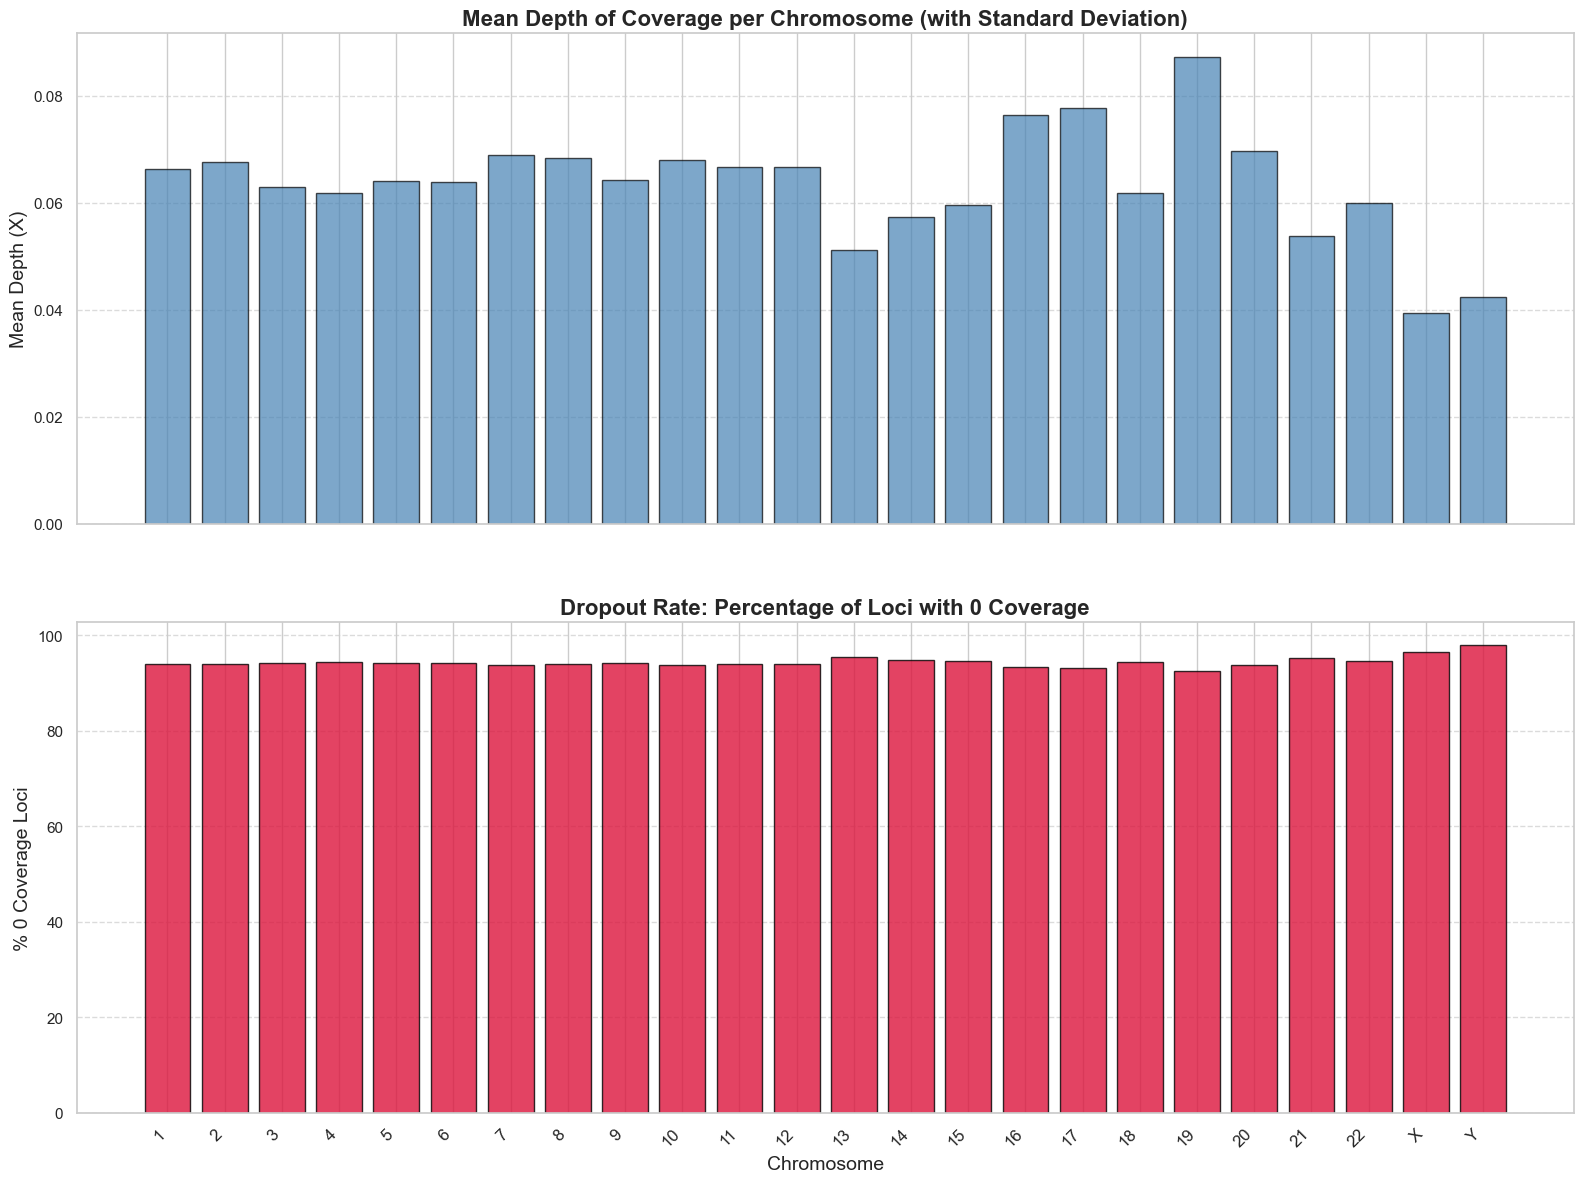

In [31]:
# Create a 2-row figure sharing the same X-axis
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

chrom_labels = df_fig1['Chromosome'].tolist()
x_pos = np.arange(len(chrom_labels))

# --- Top Subplot: Mean Coverage with Standard Deviation Error Bars ---
means = df_fig1['Mean Coverage'].tolist()
sds = df_fig1['SD Coverage'].tolist()

# axes[0].bar(x_pos, means, yerr=sds, align='center', alpha=0.7, 
#             color='steelblue', edgecolor='black', capsize=5, label='Mean Depth ± SD')


axes[0].bar(x_pos, means, align='center', alpha=0.7, 
            color='steelblue', edgecolor='black', capsize=5, label='Mean Depth ± SD')


axes[0].set_title("Mean Depth of Coverage per Chromosome (with Standard Deviation)", fontsize=16, fontweight="bold")
axes[0].set_ylabel("Mean Depth (X)", fontsize=14)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
#axes[0].legend() # Optional

# --- Bottom Subplot: Percentage of Loci with 0 Coverage ---
zero_cov = df_fig1['% Loci with 0 Coverage'].tolist()

axes[1].bar(x_pos, zero_cov, align='center', alpha=0.8, 
            color='crimson', edgecolor='black')

axes[1].set_title("Dropout Rate: Percentage of Loci with 0 Coverage", fontsize=16, fontweight="bold")
axes[1].set_ylabel("% 0 Coverage Loci", fontsize=14)
axes[1].set_xlabel("Chromosome", fontsize=14)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Format X-axis
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(chrom_labels, rotation=45, ha="right", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(hspace=0.2) # Add space between plots
plt.show()

In [29]:
def get_windowed_coverage(chrom, bam_file, window_size, available_chroms):
    """
    Calculates mean coverage in sliding windows along a chromosome using samtools bedcov.
    """
    # Handle 'chr' prefix naming convention discrepancies automatically
    target_chrom = None
    if chrom in available_chroms:
        target_chrom = chrom
    elif f"chr{chrom}" in available_chroms:
        target_chrom = f"chr{chrom}"
    elif chrom.replace("chr", "") in available_chroms:
        target_chrom = chrom.replace("chr", "")
    
    if not target_chrom:
        print(f"Warning: Chromosome {chrom} (or variant) not found in BAM index. Skipping.")
        return pd.DataFrame()

    # 1. Get chromosome length from idxstats (re-running quickly for specific chrom)
    idx_cmd = ["samtools", "idxstats", bam_file]
    idx_result = subprocess.run(idx_cmd, capture_output=True, text=True, check=True)
    chrom_len = 0
    for line in idx_result.stdout.strip().split('\n'):
        parts = line.split('\t')
        if parts[0] == target_chrom:
            chrom_len = int(parts[1])
            break
            
    if chrom_len == 0: return pd.DataFrame()

    # 2. Generate temporary BED windows in memory
    bed_lines = []
    for start in range(0, chrom_len, window_size):
        end = min(start + window_size, chrom_len)
        bed_lines.append(f"{target_chrom}\t{start}\t{end}")
    
    bed_input = "\n".join(bed_lines)
    
    # 3. Run samtools bedcov parallelized internally by samtools (-@)
    # bedcov outputs the sum of read bases in the region
    bedcov_cmd = ["samtools", "bedcov", "/dev/stdin", bam_file]
    
    try:
        # Pipe the BED windows into samtools bedcov
        proc = subprocess.Popen(bedcov_cmd, stdin=subprocess.PIPE, stdout=subprocess.PIPE, text=True)
        stdout, stderr = proc.communicate(input=bed_input)
        
        window_data = []
        for line in stdout.strip().split('\n'):
            parts = line.split('\t')
            if len(parts) < 4: continue
            # format: chrom \t start \t end \t sum_bases
            start = int(parts[1])
            end = int(parts[2])
            sum_bases = int(parts[3])
            
            region_len = end - start
            if region_len == 0: continue
            
            # Calculate Mean Depth for the window
            mean_depth = sum_bases / region_len
            
            window_data.append({
                "Chromosome": chrom, # Use standardized label (1, X, Y)
                "Position_Mb": (start + (region_len / 2)) / 1_000_000, # Midpoint in Mb
                "Mean Coverage": mean_depth
            })
            
        return pd.DataFrame(window_data)

    except Exception as e:
        print(f"Error running bedcov on {chrom}: {e}")
        return pd.DataFrame()

# Chromosomes to compare comparison
targets = ['1', 'X', 'Y']

print(f"Calculating windowed coverage ({WINDOW_SIZE/1000} kbp) along Chr1, X, Y using {THREADS} threads...")

windowed_results = []
# We still use ThreadPool to run the distinct 'target' jobs concurrently
with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
    # Pass THREADS/3 to samtools internally if bedcov supported -@, 
    # but bedcov generally doesn't leverage multithreading efficiently for 
    # small input bed files. Running jobs concurrently is better here.
    future_to_target = {
        executor.submit(get_windowed_coverage, target, BAM_FILE, WINDOW_SIZE, available_chroms): target 
        for target in targets
    }
    
    for future in concurrent.futures.as_completed(future_to_target):
        target = future_to_target[future]
        try:
            df_target = future.result()
            if not df_target.empty:
                windowed_results.append(df_target)
        except Exception as e:
            print(f"Target {target} generated an exception: {e}")

if windowed_results:
    df_windowed = pd.concat(windowed_results, ignore_index=True)
    # Ensure categorical ordering for plotting
    df_windowed['Chromosome'] = pd.Categorical(df_windowed['Chromosome'], categories=targets, ordered=True)
    print("Processing complete.")
else:
    print("No data retrieved for target chromosomes. Check BAM naming convention (e.g., 'chr1' vs '1').")
    df_windowed = pd.DataFrame()

Calculating windowed coverage (100.0 kbp) along Chr1, X, Y using 6 threads...
Processing complete.


Generating comparison plot...


/Users/ethelvol/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/ethelvol/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


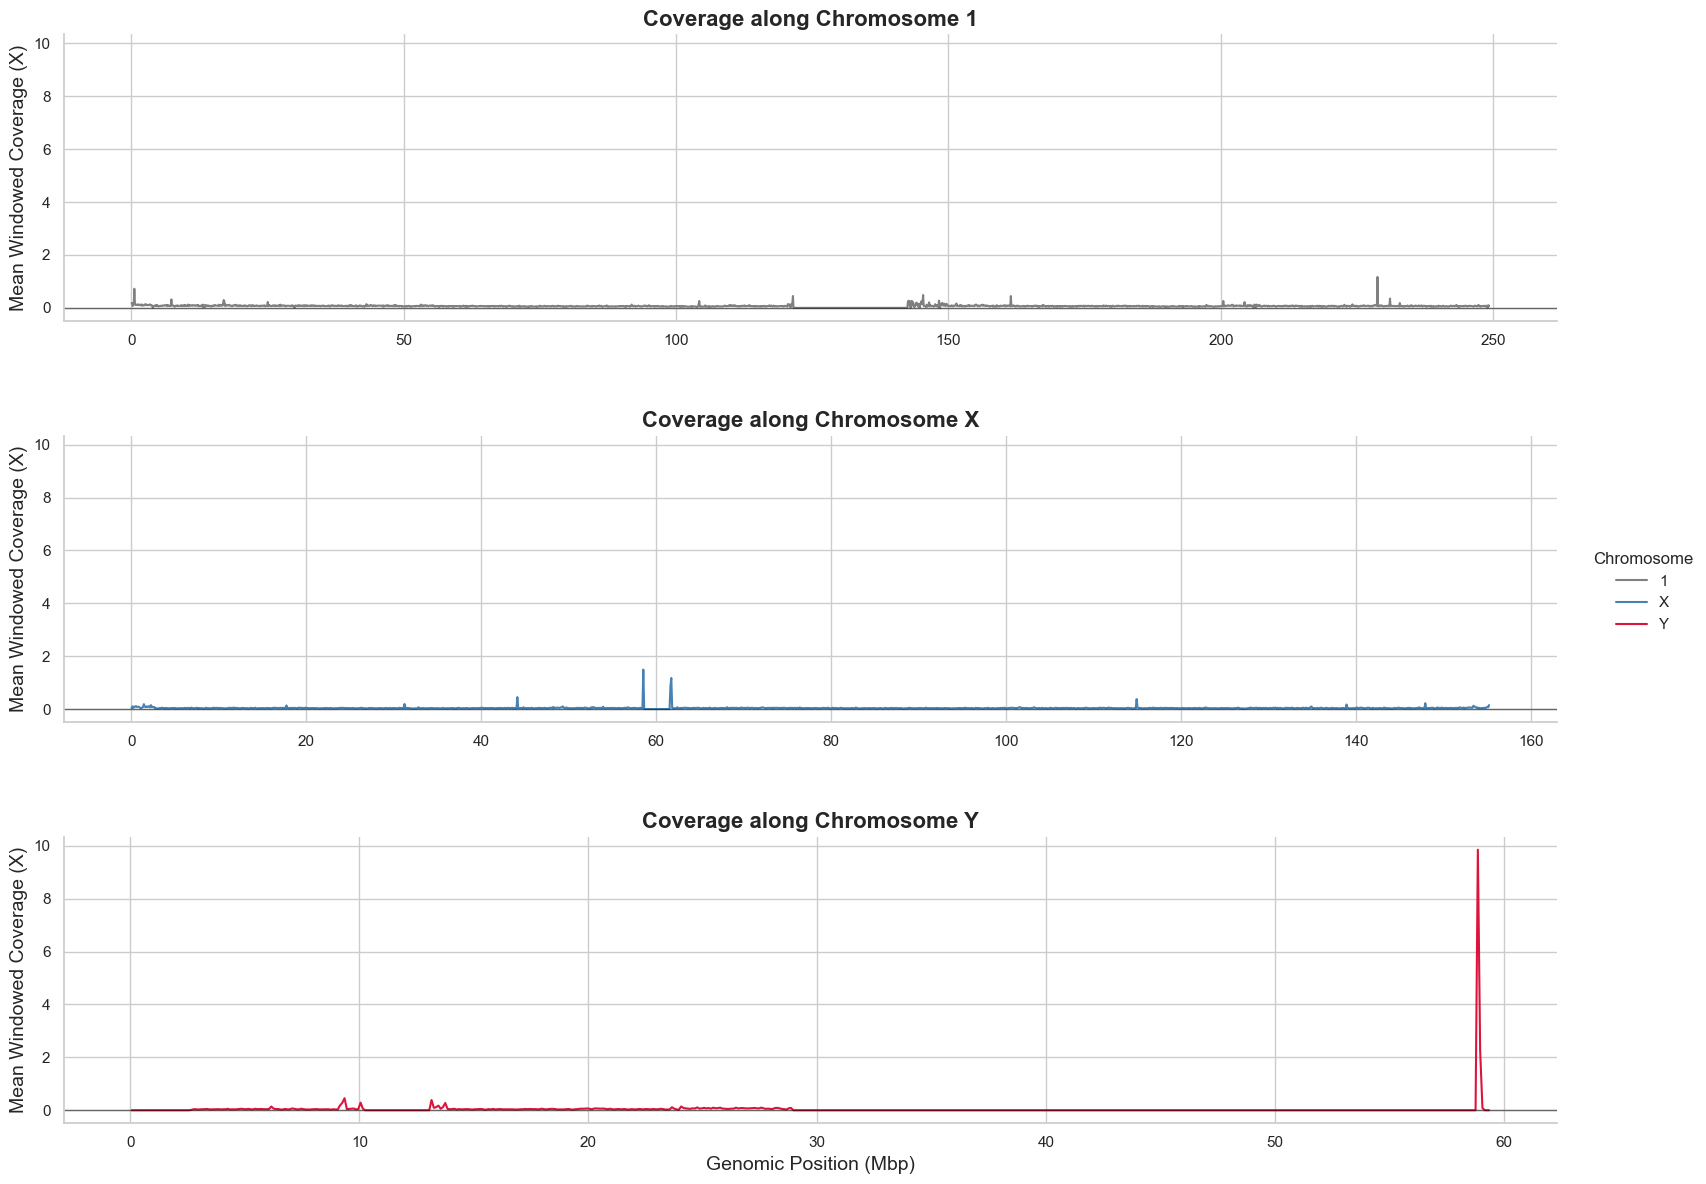

In [30]:
if not df_windowed.empty:
    print("Generating comparison plot...")
    # Visualize using faceted line plot
    g = sns.relplot(
        data=df_windowed,
        x="Position_Mb", 
        y="Mean Coverage",
        row="Chromosome", # Stack vertically
        hue="Chromosome", # Color by chromosome
        kind="line",
        height=4, 
        aspect=4, # Make them wide
        facet_kws={'sharex': False, 'sharey': True}, # Crucial: Don't share X axis (lengths differ)
        palette={'1': 'grey', 'X': 'steelblue', 'Y': 'crimson'},
        linewidth=1.5
    )

    # Adjust titles and labels
    g.set_titles("Coverage along Chromosome {row_name}", size=16, fontweight='bold')
    g.set_axis_labels("Genomic Position (Mbp)", "Mean Windowed Coverage (X)", size=14)

    # Add reference line at 0
    g.map(plt.axhline, y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

    plt.subplots_adjust(hspace=0.4) # Add space between facets
    plt.show()
else:
    print("DataFrame empty. Cannot plot.")

In [33]:
import concurrent.futures
import pandas as pd
import subprocess
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BAM_FILE = f"{DATA}/JD206_libmerged_rg_rmdup.mapped.bam" 
THREADS = 6

def get_depth_metrics(chrom, bam_file):
    """
    Executes samtools depth for a chromosome to calculate the mean 
    and the percentage of loci falling into specific read-depth bins.
    """
    cmd = ["samtools", "depth", "-aa", "-r", chrom, bam_file]
    
    # Define depth bins to categorize how many reads are at each locus
    bins = {
        "0X": 0,
        "1-10X": 0,
        "11-30X": 0,
        "31-50X": 0,
        ">50X": 0
    }
    
    total_loci = 0
    sum_depth = 0
    
    try:
        proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, text=True, bufsize=10**6)
        
        for line in proc.stdout:
            parts = line.strip().split('\t')
            if len(parts) < 3:
                continue
            
            depth = int(parts[2])
            total_loci += 1
            sum_depth += depth
            
            # Bin the locus based on its read count
            if depth == 0:
                bins["0X"] += 1
            elif depth <= 10:
                bins["1-10X"] += 1
            elif depth <= 30:
                bins["11-30X"] += 1
            elif depth <= 50:
                bins["31-50X"] += 1
            else:
                bins[">50X"] += 1
                
        proc.wait()
        
        if total_loci == 0:
            return None

        # Calculate Mean
        mean_depth = sum_depth / total_loci
        
        # Convert raw bin counts to percentages
        pct_bins = {k: (v / total_loci) * 100.0 for k, v in bins.items()}
        
        return {
            "Chromosome": chrom,
            "Mean Coverage": mean_depth,
            **pct_bins
        }

    except Exception as e:
        print(f"Error processing {chrom}: {e}")
        return None

# 1. Retrieve chromosomes
idx_cmd = ["samtools", "idxstats", BAM_FILE]
idx_result = subprocess.run(idx_cmd, capture_output=True, text=True, check=True)

chroms_to_process = []
for line in idx_result.stdout.strip().split('\n'):
    parts = line.split('\t')
    if len(parts) >= 2:
        chrom = parts[0]
        length = int(parts[1])
        if length > 1_000_000 and chrom != '*':
            chroms_to_process.append(chrom)

print(f"Calculating depth distributions for {len(chroms_to_process)} chromosomes using {THREADS} threads...")

# 2. Parallel execution
results = []
with concurrent.futures.ThreadPoolExecutor(max_workers=THREADS) as executor:
    future_to_chrom = {executor.submit(get_depth_metrics, chrom, BAM_FILE): chrom for chrom in chroms_to_process}
    for future in concurrent.futures.as_completed(future_to_chrom):
        data = future.result()
        if data:
            results.append(data)

# 3. Compile and sort DataFrame
df_dist = pd.DataFrame(results)

def natural_sort_key(s, _nsre=re.compile('([0-9]+)')):
    return [int(text) if text.isdigit() else text.lower() for text in _nsre.split(s)]

df_dist['Chromosome'] = pd.Categorical(
    df_dist['Chromosome'], 
    categories=sorted(df_dist['Chromosome'].unique(), key=natural_sort_key), 
    ordered=True
)
df_dist = df_dist.sort_values('Chromosome').reset_index(drop=True)

display(df_dist.head())

Calculating depth distributions for 25 chromosomes using 6 threads...


KeyboardInterrupt: 

In [37]:
import concurrent.futures
import pandas as pd
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
THREADS = 6
WINDOW_SIZE = 100_000 

# GRCh37/hg19 Exclusion Coordinates (PARs + Yq12 Heterochromatin)
EXCLUDE_REGIONS = {
    'X': [(10001, 2649520), (155260560, 155270560)],
    # Masking PAR1, and everything from Yq12 start to PAR2 end
    'Y': [(10001, 2649520), (28800000, 59373566)], 
    'chrX': [(10001, 2649520), (155260560, 155270560)],
    'chrY': [(10001, 2649520), (28800000, 59373566)]
}

sns.set_theme(style="whitegrid")

def generate_valid_windows(chrom, chrom_len, window_size):
    """
    Geometrically subtracts uninformative/PAR regions from the chromosome length 
    and generates valid BED windows for the remaining euchromatic intervals.
    """
    valid_intervals = [(0, chrom_len)]
    
    # Intersect and subtract excluded regions if applicable
    if chrom in EXCLUDE_REGIONS:
        for ex_start, ex_end in EXCLUDE_REGIONS[chrom]:
            new_intervals = []
            for start, end in valid_intervals:
                if end <= ex_start or start >= ex_end:
                    new_intervals.append((start, end))
                else:
                    if start < ex_start:
                        new_intervals.append((start, ex_start))
                    if end > ex_end:
                        new_intervals.append((ex_end, end))
            valid_intervals = new_intervals
            
    bed_lines = []
    for v_start, v_end in valid_intervals:
        for start in range(v_start, v_end, window_size):
            end = min(start + window_size, v_end)
            if end > start:  
                bed_lines.append(f"{chrom}\t{start}\t{end}")
            
    return "\n".join(bed_lines)

def get_filtered_windowed_coverage(chrom, bam_file, window_size, available_chroms):
    """
    Calculates mean coverage in sliding windows, strictly excluding PARs and Yq12.
    """
    target_chrom = None
    if chrom in available_chroms:
        target_chrom = chrom
    elif f"chr{chrom}" in available_chroms:
        target_chrom = f"chr{chrom}"
    elif chrom.replace("chr", "") in available_chroms:
        target_chrom = chrom.replace("chr", "")
    
    if not target_chrom:
        return pd.DataFrame()

    idx_cmd = ["samtools", "idxstats", bam_file]
    idx_result = subprocess.run(idx_cmd, capture_output=True, text=True, check=True)
    chrom_len = 0
    for line in idx_result.stdout.strip().split('\n'):
        parts = line.split('\t')
        if parts[0] == target_chrom:
            chrom_len = int(parts[1])
            break
            
    if chrom_len == 0: return pd.DataFrame()

    bed_input = generate_valid_windows(target_chrom, chrom_len, window_size)
    
    if not bed_input:
        return pd.DataFrame()

    bedcov_cmd = ["samtools", "bedcov", "/dev/stdin", bam_file]
    
    try:
        proc = subprocess.Popen(bedcov_cmd, stdin=subprocess.PIPE, stdout=subprocess.PIPE, text=True)
        stdout, stderr = proc.communicate(input=bed_input)
        
        window_data = []
        for line in stdout.strip().split('\n'):
            parts = line.split('\t')
            if len(parts) < 4: continue
            
            start = int(parts[1])
            end = int(parts[2])
            sum_bases = int(parts[3])
            
            region_len = end - start
            if region_len == 0: continue
            
            mean_depth = sum_bases / region_len
            
            window_data.append({
                "Chromosome": chrom, 
                "Position_Mb": (start + (region_len / 2)) / 1_000_000,
                "Mean Coverage": mean_depth
            })
            
        return pd.DataFrame(window_data)

    except Exception as e:
        print(f"Error running bedcov on {chrom}: {e}")
        return pd.DataFrame()

idx_cmd = ["samtools", "idxstats", BAM_FILE]
idx_result = subprocess.run(idx_cmd, capture_output=True, text=True, check=True)
available_chroms = [line.split('\t')[0] for line in idx_result.stdout.strip().split('\n') if line]

targets = ['1', 'X', 'Y']
print(f"Calculating highly filtered windowed coverage along Chr1, X, Y using {THREADS} threads...")

windowed_results = []
with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
    future_to_target = {
        executor.submit(get_filtered_windowed_coverage, target, BAM_FILE, WINDOW_SIZE, available_chroms): target 
        for target in targets
    }
    
    for future in concurrent.futures.as_completed(future_to_target):
        try:
            df_target = future.result()
            if not df_target.empty:
                windowed_results.append(df_target)
        except Exception as e:
            print(f"Error processing target: {e}")

if windowed_results:
    df_windowed_clean = pd.concat(windowed_results, ignore_index=True)
    df_windowed_clean['Chromosome'] = pd.Categorical(df_windowed_clean['Chromosome'], categories=targets, ordered=True)
    print("Processing complete.")
else:
    df_windowed_clean = pd.DataFrame()

Calculating highly filtered windowed coverage along Chr1, X, Y using 6 threads...
Processing complete.


Generating updated comparison plot...


/Users/ethelvol/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/ethelvol/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


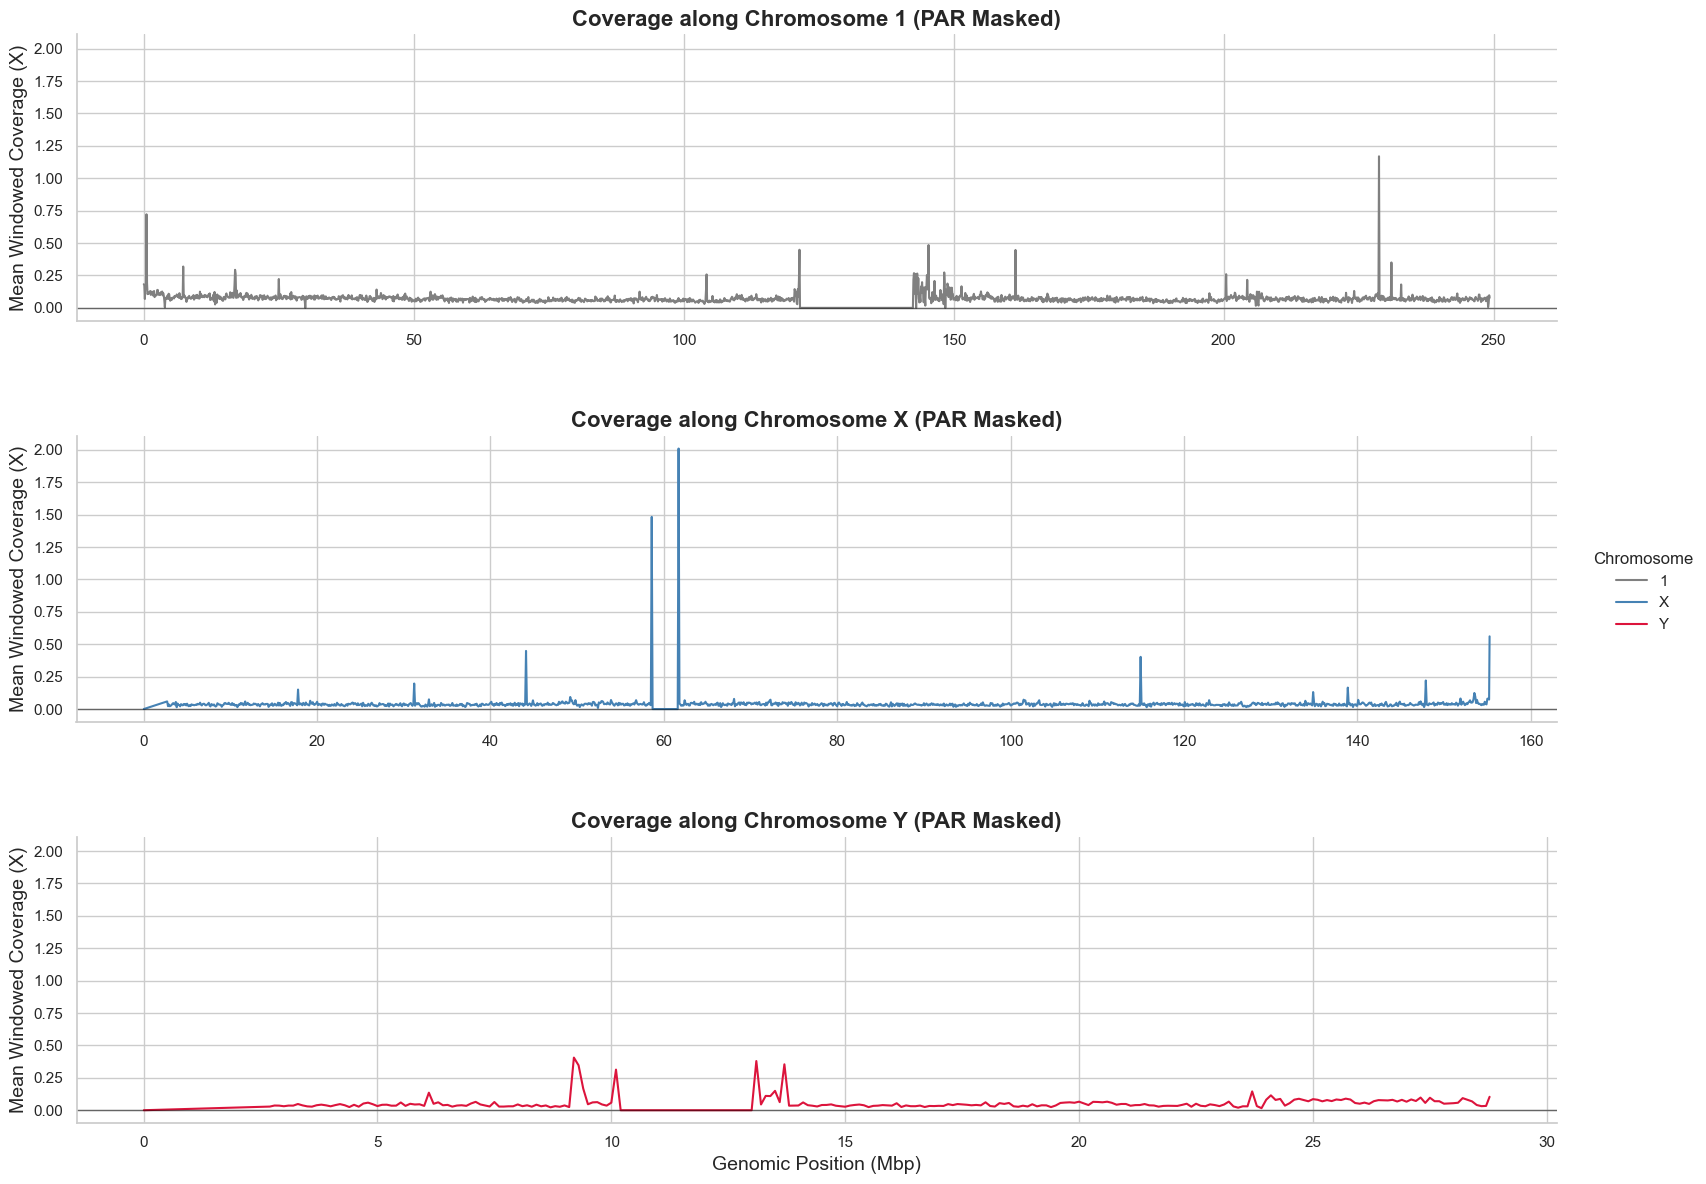

In [38]:
if not df_windowed_clean.empty:
    print("Generating updated comparison plot...")
    
    g = sns.relplot(
        data=df_windowed_clean,
        x="Position_Mb", 
        y="Mean Coverage",
        row="Chromosome", 
        hue="Chromosome", 
        kind="line",
        height=4, 
        aspect=4, 
        facet_kws={'sharex': False, 'sharey': True}, 
        palette={'1': 'grey', 'X': 'steelblue', 'Y': 'crimson'},
        linewidth=1.5
    )

    g.set_titles("Coverage along Chromosome {row_name} (PAR Masked)", size=16, fontweight='bold')
    g.set_axis_labels("Genomic Position (Mbp)", "Mean Windowed Coverage (X)", size=14)

    g.map(plt.axhline, y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

    plt.subplots_adjust(hspace=0.4) 
    plt.show()
else:
    print("DataFrame empty. Cannot plot.")